# 1. Real GDP across US states

# 1.1

In [ ]:
%pip install fredapi

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from fredapi import Fred # Import FRED API

from states import STATES # Import list of states

# FRED API
fred = Fred(api_key="4f86a7b51eb44046f4bc746cb4acc02a")

# Dictionaries
gdp = {}
pop = {}

# Download data
for state in STATES:
    print(f"Downloading {state}...")

    gdp[state] = fred.get_series(f"{state}RGSP")
    pop[state] = fred.get_series(f"{state}POP")

# Convert to DataFrames
df_gdp = pd.DataFrame(gdp)
df_pop = pd.DataFrame(pop)

In [37]:
# Convert index to year
df_gdp.index = pd.to_datetime(df_gdp.index).year 
df_pop.index = pd.to_datetime(df_pop.index).year 

display(df_gdp.head())
display(df_pop.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1970,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1970,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1970,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
1970,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
1970,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1970,4320.281,608.846,4552.207,2524.007,32217.708,3891.293,3268.514,735.024,14683.350,7486.094,...,730.855,5378.433,19355.427,2065.397,588.665,6732.878,5604.105,1815.588,5200.235,480.031
1970,4351.037,615.205,4667.277,2538.202,32682.794,3968.967,3272.563,744.066,14908.230,7636.522,...,730.789,5432.679,19712.389,2100.562,590.579,6789.225,5687.832,1811.688,5222.124,480.045
1970,4369.862,619.500,4778.332,2551.373,33145.121,4056.133,3282.031,753.538,15111.244,7788.240,...,733.133,5483.535,20044.141,2129.836,593.740,6872.912,5756.361,1806.928,5250.446,479.602
1970,4452.173,627.963,5160.586,2678.588,33987.977,4326.921,3411.777,786.373,16047.515,8227.303,...,755.844,5703.719,20944.499,2244.502,609.618,7105.817,5910.512,1807.021,5373.999,494.300
1970,4467.634,633.714,5273.477,2691.571,34479.458,4425.687,3432.835,795.699,16356.966,8377.038,...,757.972,5750.789,21319.622,2283.715,612.223,7198.362,5985.722,1801.481,5406.835,494.657


In [ ]:
# Keep only common years
common_years = df_gdp.index.intersection(df_pop.index)

# Drop years with missing observations
df_gdp = df_gdp.loc[common_years]
df_pop = df_pop.loc[common_years]

# Drop states with missing observations
df_gdp = df_gdp.dropna(axis=1)
df_pop = df_pop.dropna(axis=1)

# Print summary
print(f"Years left: {len(df_gdp)}")
print(f"States left: {len(df_gdp.columns)}")

Years left: 29
States left: 50


In [38]:
df_gdp_pc = df_gdp / df_pop * 1000

display(df_gdp_pc.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
1970,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1970,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1970,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
1970,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
1970,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


In [6]:
# First and last year
first = df_gdp_pc.iloc[0]
last = df_gdp_pc.iloc[-1]

print("First year")
print("Highest:", first.max(), "State:", first.idxmax())
print("Lowest:", first.min(), "State:", first.idxmin())
print("Ratio:", first.max() / first.min())
print("Average:", first.mean())

print()

print("Last year")
print("Highest:", last.max(), "State:", last.idxmax())
print("Lowest:", last.min(), "State:", last.idxmin())
print("Ratio:", last.max() / last.min())
print("Average:", last.mean())

First year
Highest: 69748.74289819108 State: DE
Lowest: 32062.68099960517 State: ID
Ratio: 2.1753871081164418
Average: 44592.94585067332

Last year
Highest: 94701.98791376667 State: NY
Lowest: 42434.02523898502 State: MS
Ratio: 2.2317465142751054
Average: 64674.46481951765


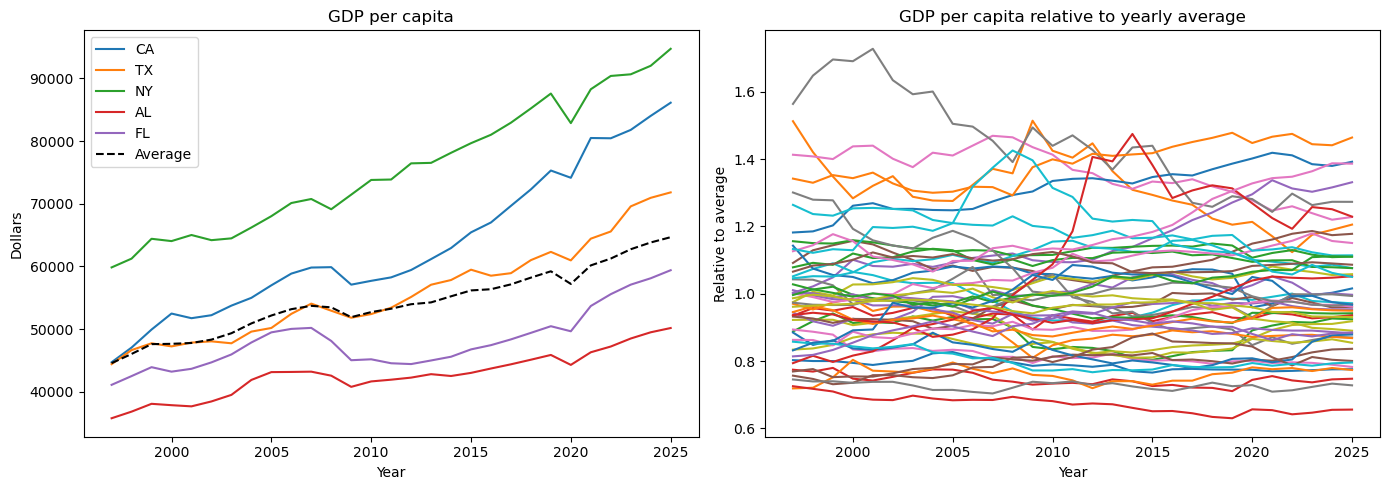

In [ ]:
# Average GDP per capita across states
average = df_gdp_pc.mean(axis=1)

# A few states of your choice
states = ["CA", "TX", "NY", "AL", "FL"]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Panel 1
for state in states:
    ax[0].plot(df_gdp_pc.index, df_gdp_pc[state], label=state) # Plot GDP per capita for each state

ax[0].plot(df_gdp_pc.index, average, "k--", label="Average")
ax[0].set_title("GDP per capita")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Dollars")
ax[0].legend()

# Panel 2
relative = df_gdp_pc.divide(average, axis=0)

for state in df_gdp_pc.columns:
    ax[1].plot(relative.index, relative[state])

ax[1].set_title("GDP per capita relative to yearly average")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Relative to average")

plt.tight_layout()
plt.show()

# 1.2

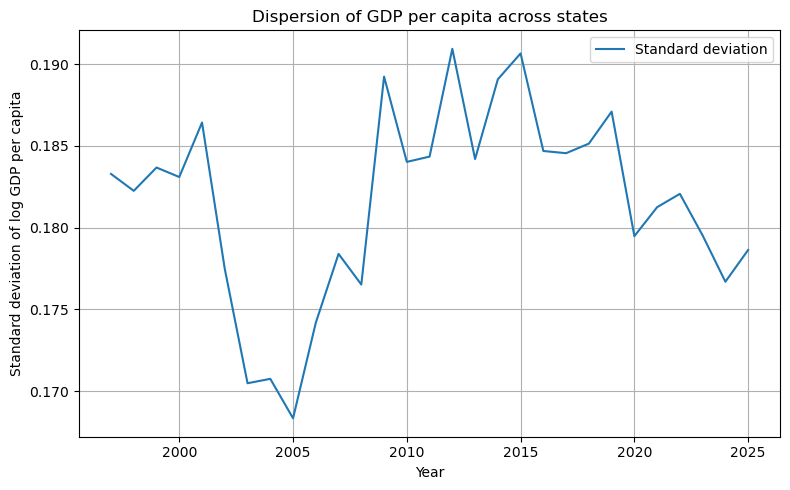

In [13]:
# Log GDP per capita
log_gdp_pc = np.log(df_gdp_pc)

# Standard deviation across states for each year
std = log_gdp_pc.std(axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(std.index, std)
plt.xlabel("Year")
plt.ylabel("Standard deviation of log GDP per capita")
plt.title("Dispersion of GDP per capita across states")
plt.grid(True)
plt.legend(["Standard deviation"])
plt.tight_layout()
plt.show()

In [ ]:
# Print summary
print("First year:", std.iloc[0])
print("Last year:", std.iloc[-1])

print("Highest:", std.max())
print("Year:", std.idxmax())

print("Lowest:", std.min())
print("Year:", std.idxmin())

First year: 0.18328585778108922
Last year: 0.17863248031034773
Highest: 0.19094282639042143
Year: 2012
Lowest: 0.16833338925603575
Year: 2005


**Answer:** The dispersion of log GDP per capita across states is fairly stable over time. There is a noticeable decline from about 2001 to 2005, followed by an increase until around 2012. One possible explanation is that the housing boom in the early 2000s benefited some states more than others, while the housing market crash during the Great Recession reduced these differences. However, the figure alone cannot confirm this explanation.

# 1.3

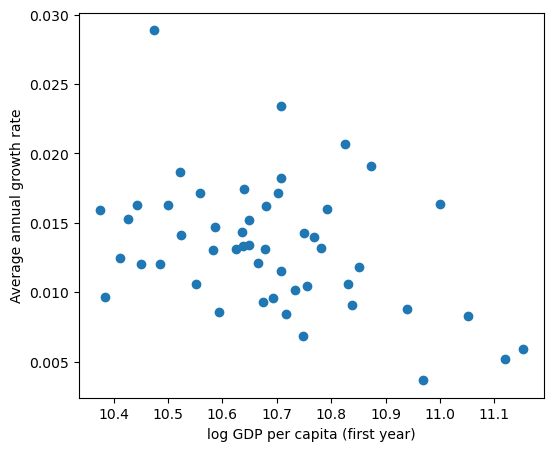

In [ ]:
# Average annual growth rate denominator
T = df_gdp_pc.index[-1] - df_gdp_pc.index[0]

# Average annual growth rate
g = (np.log(last) - np.log(first)) / T

# Plot
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.show()

a = 0.11808936079725181
b = -0.009802151612523426
Correlation = -0.3886167658049338


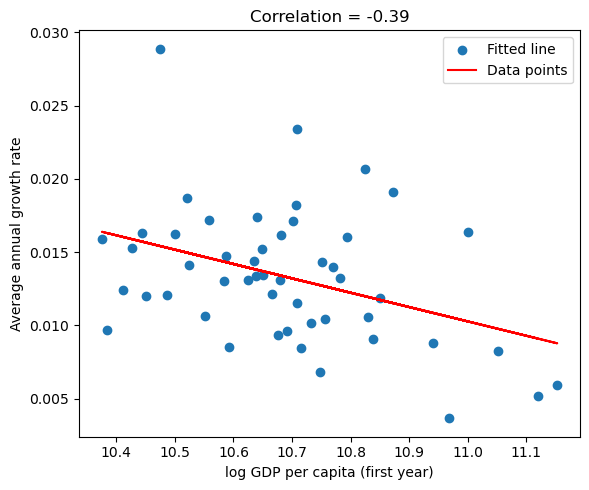

In [ ]:
# Fit line: g = a + b*log(first)
b, a = np.polyfit(np.log(first), g, 1)

# Correlation
corr = np.corrcoef(np.log(first), g)[0,1]

# Print results
print("a =", a)
print("b =", b)
print("Correlation =", corr)

# Scatter plot and fitted line
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

# Fitted line
x = np.log(first)
plt.plot(x, a + b*x, color="red")

# Plot
plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.legend(["Fitted line", "Data points"])
plt.title(f"Correlation = {corr:.2f}")
plt.tight_layout()
plt.show()

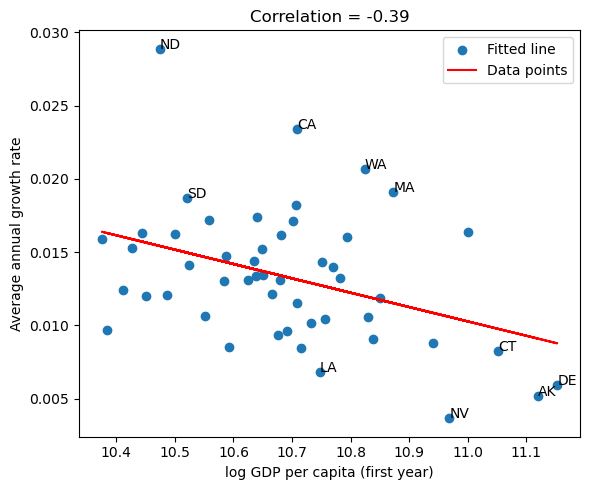

In [ ]:
# Five highest and five lowest growth states
highest = g.nlargest(5)
lowest = g.nsmallest(5)

# Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(np.log(first), g)

# Fitted line
x = np.log(first)
plt.plot(x, a + b*x, color="red")

# Add labels
for state in highest.index:
    plt.text(np.log(first[state]), g[state], state)

for state in lowest.index:
    plt.text(np.log(first[state]), g[state], state)

# Plot
plt.xlabel("log GDP per capita (first year)")
plt.ylabel("Average annual growth rate")
plt.legend(["Fitted line", "Data points"])
plt.title(f"Correlation = {corr:.2f}")
plt.tight_layout()
plt.show()

In [22]:
# Speed of convergence
lam = -np.log(1 + b * T) / T

# Half-life
h = np.log(2) / lam

print("Lambda:", lam)
print("Half-life:", h)

Lambda: 0.011458550416960303
Half-life: 60.491698804587685


**Answer:** The fitted line has a negative slope, showing that states with lower initial GDP per capita generally had higher growth rates than richer states, indicating convergence. The points are fairly scattered around the line, but with a correlation of -0.39 there is a moderate negative relationship, so the fit is reasonable but not very strong.

# 1.4

In [ ]:
from states import REGION

# GDP per capita relative to the US average
relative = df_gdp_pc.div(df_gdp_pc.mean(axis=1), axis=0)

# Average for each region
region_avg = pd.DataFrame()

for region in set(REGION.values()):
    states = [state for state in REGION if REGION[state] == region] # Get states in the region
    region_avg[region] = relative[states].mean(axis=1)

# Display the first few rows of the region averages
display(region_avg.head())

# Print the number of states in each region
for region in set(REGION.values()):
    states = [state for state in REGION if REGION[state] == region] # Get states in the region
    print(region, len(states))

,South,Midwest,West,Northeast
1997,0.951318,0.968332,1.028682,1.087340
1998,0.957887,0.968472,1.020313,1.087564
1999,0.958916,0.962879,1.021444,1.091557
2000,0.943301,0.976595,1.014661,1.110827
2001,0.948591,0.969318,1.008820,1.119563


South 16
Midwest 12
West 13
Northeast 9


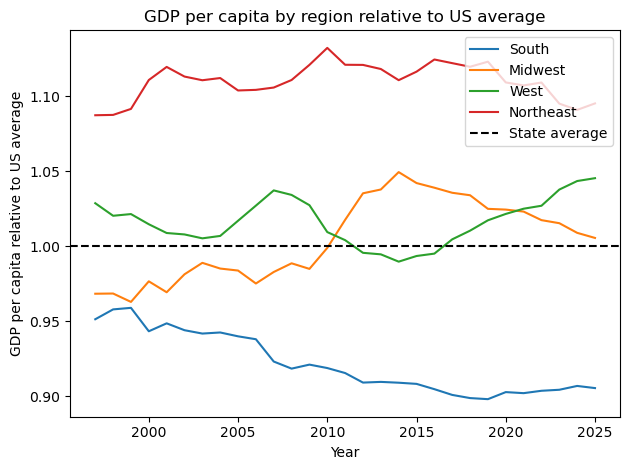

In [40]:
# Plot GDP per capita by region relative to US average
plt.plot(region_avg)

# Add horizontal line at y=1 to indicate the state average
plt.axhline(y=1, color="black", linestyle="--", label="State average")

# Plot
plt.xlabel("Year")
plt.ylabel("GDP per capita relative to US average")
plt.legend(region_avg.columns.tolist() + ["State average"])
plt.title("GDP per capita by region relative to US average")
plt.tight_layout()
plt.show()

In [42]:
# First year
print("First year")
print(region_avg.iloc[0])

print() # Add a blank line for better readability

# Last year
print("Last year")
print(region_avg.iloc[-1])

print() # Add a blank line for better readability

# Change
print("Change")
print(region_avg.iloc[-1] - region_avg.iloc[0])

First year
South        0.951318
Midwest      0.968332
West         1.028682
Northeast    1.087340
Name: 1997, dtype: float64

Last year
South        0.905418
Midwest      1.005527
West         1.045378
Northeast    1.095232
Name: 2025, dtype: float64

Change
South       -0.045900
Midwest      0.037194
West         0.016696
Northeast    0.007892
dtype: float64


**Answer:** The South moves the most over the sample period. Its relative GDP per capita decreases, meaning that the South falls further below the national average.